# 12-01 TabPFN Validation Learning Curve

Dieses Notebook wertet vorhandene Legacy-Learning-Curve-Ergebnisse aus. Es ist bewusst als Kontextanalyse angelegt und legt keine finalen Hyperparameter fest.

Methodisch beantwortet dieses Notebook die Frage, ob frühere TabPFN-Läufe Hinweise auf stabile Trainingsgrößen, auffällige API-Kosten oder problematische Modellvarianten liefern. Die eigentliche Modellauswahl erfolgt aber erst in `12-02` mit dem aktuellen `Top10`-Target und der Validierungsmetrik `roc_auc`.

Damit bleibt die zeitliche Trennung sauber: Alte Ergebnisse dürfen erklärt und eingeordnet werden, ersetzen aber keine neue Validierung auf dem aktuellen 2023er Split.

## Warum dieses Notebook trotz Legacy-Charakter wichtig bleibt

Zwischenergebnisse werden fachlich eingeordnet: Was sagt eine Kurve aus? Welche Metrik ist nur Proxy? Welche Entscheidung folgt daraus nicht? Genau diese Funktion hat `12-01` für alte TabPFN-Learning-Curve-Läufe. Die Ergebnisse können Hinweise auf stabile Kontextgrößen oder API-Verbrauch geben, aber sie sind nicht die finale Hyperparameterwahl.

**Methodische Begrenzung:** Viele Legacy-Läufe entstanden unter einem älteren Plan. Teilweise wurden andere Scores, andere Zieldefinitionen oder andere Modellpfade verwendet. Deshalb wird in diesem Notebook nicht nach einem finalen Gewinner gesucht. Stattdessen wird transparent dokumentiert, welche historischen Classifier-Zeilen überhaupt noch als Kontext zur neuen `TabPFNClassifier`-Strategie passen.

**Interpretation der Outputs:** Jede Tabelle ist als Kontexttabelle zu lesen. Sie darf Hypothesen für `12-02` motivieren, aber sie darf keine Entscheidung auf dem Testsplit 2024/2025 vorwegnehmen.

## Methodische Langfassung: Was eine Legacy-Learning-Curve leisten kann und was nicht

Dieses Notebook ist bewusst kein Tuning-Notebook. Seine Aufgabe besteht darin, ältere Learning-Curve-Ergebnisse so aufzubereiten, dass sie als Kontext gelesen werden können. Historische TabPFN-Läufe können Hinweise auf Laufzeit, Kontextgröße oder Stabilität geben, aber sie ersetzen nicht die neue Validierung aus `12-02`.

**Warum Legacy überhaupt ansehen?** TabPFN-Läufe können teuer oder zeitaufwendig sein. Wenn bereits frühere Experimente existieren, wäre es methodisch unsauber, sie komplett zu ignorieren. Sie können zeigen, ob sehr kleine Trainingskontexte instabil waren, ob größere Kontexte sichtbare Verbesserungen brachten oder ob API-Usage stark mit der Kontextgröße skaliert. Diese Informationen helfen bei der Interpretation der neuen Ergebnisse, auch wenn sie keine finalen Parameter festlegen.

**Warum Legacy nicht entscheiden darf:** Die alten Ergebnisse entstanden teilweise unter einer anderen Zieldefinition oder mit anderen Scores. Manche Zeilen beziehen sich auf `target_ordinal`, andere auf alte Rankinglogiken oder Client-Versuche. Dadurch sind sie nicht eins zu eins mit dem neuen Plan vergleichbar. Würde man daraus direkt die finale Konfiguration ableiten, wäre die neue Methode methodisch vermischt: Ein Teil der Entscheidung käme aus alten Annahmen, ein anderer Teil aus den neuen binären Targets.

**Rolle der Classifier-Filterung:** Die Filterung auf Classifier-Zeilen ist deshalb ein methodischer Schutz. Nur diese Zeilen passen überhaupt grob zur neuen `TabPFNClassifier`-Strategie. Selbst diese Zeilen bleiben aber Kontext. Sie können zeigen, welche Trainingsgrößen historisch interessant waren, welche Scores beobachtet wurden und wie Verbrauchsdaten aussahen. Die neue verbindliche Auswahl geschieht erst in `12-02` mit `Top10` und `roc_auc` auf dem Validierungssplit 2023.

**Rolle von Usage und Laufzeit:** Für TabPFN ist dieser Aspekt noch stärker, als für die anderen Modelle, weil API-Läufe und Cache-Hits unterschieden werden müssen. Eine lokal geladene CSV ist nicht gleichzusetzen mit einem neuen Modelllauf. Dieses Notebook dokumentiert daher vorhandene Legacy-Usage, ohne daraus eine Modellgüte abzuleiten. Laufzeit und Verbrauch sind praktische Nebenbedingungen, nicht die primäre Qualitätsmetrik.

**Wie die Outputs zu lesen sind:** Die Tabellen und Charts beantworten jeweils eine begrenzte Frage. Die Ladeübersicht zeigt, ob Legacy-Dateien vorhanden sind. Die Classifier-Tabelle zeigt, welche historischen Zeilen noch zur Modellfamilie passen. Die beste Zeile je Kontextgröße zeigt historische Muster, aber keinen neuen Gewinner. Die Usage-Tabelle hilft bei der Einschätzung praktischer Kosten. In Summe entsteht ein nachvollziehbarer Übergang von alten Versuchen zur neuen, saubereren TabPFN-Reihe.

In [1]:
# Dieser Codeblock richtet Pfade und Basisimporte für die Legacy-Auswertung ein.

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

start_path = Path.cwd()
PROJECT_ROOT = None
for candidate in [start_path, *start_path.parents]:
    has_model_data = (candidate / "data" / "model_data").exists()
    has_notebooks = (candidate / "src" / "Notebooks").exists()
    if has_model_data and has_notebooks:
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError("Projektwurzel mit data/model_data und src/Notebooks nicht gefunden.")

MODEL_DATA_DIR = PROJECT_ROOT / "data" / "model_data"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TABPFN_DIR = PROCESSED_DIR / "tabpfn"
LEGACY_DIR = PROCESSED_DIR / "tabpfn_3_experiments"

path_overview = pd.DataFrame([
    {"name": "PROJECT_ROOT", "path": str(PROJECT_ROOT), "exists": PROJECT_ROOT.exists()},
    {"name": "LEGACY_DIR", "path": str(LEGACY_DIR), "exists": LEGACY_DIR.exists()},
    {"name": "TABPFN_DIR", "path": str(TABPFN_DIR), "exists": TABPFN_DIR.exists()},
])

print("=" * 88)
print("TABPFN LEGACY LEARNING CURVE: Pfadprüfung")
print("=" * 88)
display(path_overview)

TABPFN LEGACY LEARNING CURVE: Pfadprüfung


,name,path,exists
0,PROJECT_ROOT,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
1,LEGACY_DIR,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True
2,TABPFN_DIR,/Users/roberthendrich/GADA-Group3-Cycling-Stag...,True


### Interpretation der Pfadprüfung

Wenn `LEGACY_DIR` fehlt, ist das kein Fehler der neuen TabPFN-Methode. Es bedeutet nur, dass keine historischen Learning-Curve-Dateien angezeigt werden können. Das Notebook bleibt in diesem Fall trotzdem nützlich, weil es die fehlende Evidenz sichtbar macht.

In [2]:
# Leseschlüssel für die Legacy-Ladezelle:
# 1. Jede erwartete CSV wird einzeln geprüft und geladen.
# 2. Fehlende Dateien erzeugen Warnungen, aber keinen Abbruch.
# 3. Die Ladeübersicht zeigt, welche historischen Informationen tatsächlich verfügbar sind.

# Historische CSV-Dateien werden direkt im Loop geladen; fehlende Dateien bleiben als Warnung sichtbar.

RESULT_DIR = TABPFN_DIR / "01_validation_learning_curve"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

legacy_files = {
    "summary": "tabpfn_client_lc_val2023_summary.csv",
    "stage_metrics": "tabpfn_client_lc_val2023_stage_metrics.csv",
    "usage_summary": "tabpfn_client_lc_val2023_usage_summary.csv",
    "sampling_plan": "tabpfn_client_lc_val2023_sampling_plan.csv",
}

loaded_legacy = {}
load_rows = []
for object_name, file_name in legacy_files.items():
    file_path = LEGACY_DIR / file_name
    if file_path.exists():
        loaded_legacy[object_name] = pd.read_csv(file_path)
        status = "loaded"
        rows = len(loaded_legacy[object_name])
        columns = loaded_legacy[object_name].shape[1]
    else:
        warnings.warn(f"Legacy-Datei fehlt: {file_path}")
        loaded_legacy[object_name] = pd.DataFrame()
        status = "missing"
        rows = 0
        columns = 0
    load_rows.append({
        "object": object_name,
        "file": file_name,
        "status": status,
        "rows": rows,
        "columns": columns,
    })

summary = loaded_legacy["summary"]
stage_metrics = loaded_legacy["stage_metrics"]
usage_summary = loaded_legacy["usage_summary"]
sampling_plan = loaded_legacy["sampling_plan"]
load_overview = pd.DataFrame(load_rows)

print("=" * 88)
print("TABPFN LEGACY LEARNING CURVE: Geladene Dateien")
print("=" * 88)
display(load_overview)

TABPFN LEGACY LEARNING CURVE: Geladene Dateien


,object,file,status,rows,columns
0,summary,tabpfn_client_lc_val2023_summary.csv,loaded,20,21
1,stage_metrics,tabpfn_client_lc_val2023_stage_metrics.csv,loaded,1140,14
2,usage_summary,tabpfn_client_lc_val2023_usage_summary.csv,loaded,24,19
3,sampling_plan,tabpfn_client_lc_val2023_sampling_plan.csv,loaded,4,13


### Interpretation der geladenen Legacy-Dateien

Die Ladeübersicht zeigt sofort, ob die folgenden Tabellen belastbar sind. Eine leere Summary bedeutet, dass keine historische Classifier-Einordnung möglich ist. Eine vorhandene Usage-Datei hilft dagegen, spätere Laufzeit- und Verbrauchsdiskussionen besser einzuordnen.

## Legacy-Classifier-Zeilen isolieren

In diesem Abschnitt werden alte Ergebnisdateien geladen und auf echte Classifier-Zeilen gefiltert. Nicht-Classifier-Ergebnisse werden nicht gelöscht, aber sie werden nur als historischer Kontext behandelt.

Diese Unterscheidung ist wichtig, weil der neue TabPFN-Plan ausschließlich den `TabPFNClassifier` nutzt. Ergebnisse aus anderen Modellfamilien oder Zieldefinitionen dürfen nicht stillschweigend in die neue Modellwahl eingehen.

Nach der Codezelle sollte sichtbar sein, welche alten Läufe überhaupt als Classifier-Kontext geeignet sind.

### Methodische Einordnung

Die Filterung auf Classifier-Zeilen ist keine technische Nebensache. Sie entscheidet, welche historischen Resultate überhaupt noch zur neuen Strategie passen. Alte Nicht-Classifier-Läufe können weiterhin erklären, wie sich die Projektidee entwickelt hat, aber sie dürfen nicht als Evidenz für die finale `TabPFNClassifier`-Auswahl dienen.

In [3]:
# Die alten Ergebnisse werden auf Classifier-Zeilen reduziert, weil nur diese zum neuen TabPFN-Plan passen.

if summary.empty:
    classifier_summary = pd.DataFrame()
    non_classifier_summary = pd.DataFrame()
else:
    assert "model_type" in summary.columns
    assert "target_rows" in summary.columns
    classifier_mask = summary["model_type"].astype(str).str.contains("classifier", case=False, na=False)
    classifier_summary = summary[classifier_mask].copy()
    non_classifier_summary = summary[~classifier_mask].copy()

classifier_summary.to_csv(RESULT_DIR / "legacy_learning_curve_classifier_summary.csv", index=False)

classifier_context = pd.DataFrame([
    {"row_type": "classifier_context", "rows": len(classifier_summary), "use_in_new_plan": "anzeigen, aber nicht final auswählen"},
    {"row_type": "non_classifier_legacy", "rows": len(non_classifier_summary), "use_in_new_plan": "nur historische Einordnung"},
])

print("=" * 88)
print("TABPFN LEGACY LEARNING CURVE: Classifier-Kontext")
print("=" * 88)
display(classifier_context)
display(classifier_summary.head(20))

TABPFN LEGACY LEARNING CURVE: Classifier-Kontext


,row_type,rows,use_in_new_plan
0,classifier_context,16,"anzeigen, aber nicht final auswählen"
1,non_classifier_legacy,4,nur historische Einordnung


,rows,n_stages,spearman_global,ndcg_at_5,ndcg_at_10,ndcg_at_20,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_20_accuracy,mean_stage_spearman,run_label,model_type,score_name,target,target_rows,actual_train_rows,seed,n_estimators,model_path,balance_probabilities
0,8897,57,0.310402,0.391817,0.399167,0.431884,0.175439,0.368421,0.491228,0.578947,0.304621,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,expected_value,target_ordinal,25000,25093,42,4,auto,True
1,8897,57,0.309019,0.393532,0.405194,0.436275,0.210526,0.368421,0.491228,0.561404,0.303848,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,25000,25093,42,4,auto,True
2,8897,57,0.315048,0.389547,0.400668,0.439465,0.175439,0.315789,0.491228,0.614035,0.308237,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top20_probability,target_ordinal,25000,25093,42,4,auto,True
3,8897,57,0.297751,0.385443,0.377621,0.418448,0.175439,0.350877,0.438596,0.561404,0.294285,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top5_probability,target_ordinal,25000,25093,42,4,auto,True
4,8897,57,0.297541,0.382235,0.385198,0.420833,0.140351,0.368421,0.491228,0.578947,0.294577,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,expected_value,target_ordinal,50000,50007,42,4,auto,True
5,8897,57,0.296142,0.378754,0.391211,0.419700,0.157895,0.333333,0.526316,0.578947,0.293347,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,50000,50007,42,4,auto,True
6,8897,57,0.303196,0.367225,0.386166,0.416073,0.122807,0.280702,0.491228,0.596491,0.298984,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top20_probability,target_ordinal,50000,50007,42,4,auto,True
7,8897,57,0.280927,0.360969,0.364068,0.402385,0.122807,0.350877,0.438596,0.578947,0.281939,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top5_probability,target_ordinal,50000,50007,42,4,auto,True
8,8897,57,0.305263,0.384194,0.385371,0.429591,0.140351,0.368421,0.491228,0.578947,0.303959,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,expected_value,target_ordinal,75000,75030,42,4,auto,True
9,8897,57,0.304678,0.399179,0.398461,0.443193,0.157895,0.368421,0.508772,0.596491,0.303340,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,75000,75030,42,4,auto,True


### Interpretation der Classifier-Tabelle

Nur die Classifier-Zeilen haben direkten Bezug zum neuen TabPFN-Plan. Nicht-Classifier-Zeilen können interessant sein, bleiben aber methodisch außerhalb der neuen Pipeline. Diese strikte Trennung verhindert, dass historische Experimente unbemerkt als aktuelle Evidenz gelesen werden.

## Beste historische Classifier-Zeile pro Trainingsgröße

Hier wird pro historischer Trainingsgröße die beste alte Classifier-Zeile ausgewählt. Falls `roc_auc` vorhanden ist, wird sie bevorzugt; andernfalls dient `ndcg_at_10` nur als Legacy-Kontext.

Diese Tabelle ist keine finale Entscheidungstabelle. Sie hilft lediglich dabei, frühere Beobachtungen strukturiert zu lesen und später mit dem sauberen Top10-Tuning aus `12-02` zu vergleichen.

Die Interpretation sollte daher vorsichtig bleiben: Ein alter guter Wert ist ein Hinweis, aber noch kein neues Hyperparameter-Ergebnis.

### Interpretation der historischen Kontextgröße

Wenn eine größere Kontextgröße historisch stabiler war, ist das ein Hinweis, aber kein Beweis für die neue Pipeline. Die alten Läufe können andere Zieldefinitionen und andere Scores enthalten. Deshalb wird die beste Zeile je Kontextgröße nur als Lesebrücke exportiert. Die echte Entscheidung liegt erst in `12-02`, wo `Top10` und `roc_auc` verbindlich sind.

In [7]:
# Pro Trainingsgröße wird die beste historische Zeile bestimmt, aber nur als Kontext für das spätere Tuning.

if classifier_summary.empty:
    best_by_context = pd.DataFrame()
    sort_metric = None
else:
    sort_metric = "roc_auc" if "roc_auc" in classifier_summary.columns else "ndcg_at_10"
    best_by_context = (
        classifier_summary
        .sort_values(["target_rows", sort_metric], ascending=[True, False])
        .groupby("target_rows", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

best_by_context.to_csv(RESULT_DIR / "legacy_learning_curve_best_by_context.csv", index=False)

print("=" * 88)
print("TABPFN LEGACY LEARNING CURVE: Beste historische Classifier-Zeile je Kontextgröße")
print("=" * 88)
print(f"Sortiermetrik: {sort_metric}")
display(best_by_context)

TABPFN LEGACY LEARNING CURVE: Beste historische Classifier-Zeile je Kontextgröße
Sortiermetrik: ndcg_at_10


,rows,n_stages,spearman_global,ndcg_at_5,ndcg_at_10,ndcg_at_20,top_1_accuracy,top_5_accuracy,top_10_accuracy,top_20_accuracy,mean_stage_spearman,run_label,model_type,score_name,target,target_rows,actual_train_rows,seed,n_estimators,model_path,balance_probabilities
0,8897,57,0.309019,0.393532,0.405194,0.436275,0.210526,0.368421,0.491228,0.561404,0.303848,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,25000,25093,42,4,auto,True
1,8897,57,0.296142,0.378754,0.391211,0.419700,0.157895,0.333333,0.526316,0.578947,0.293347,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,50000,50007,42,4,auto,True
2,8897,57,0.310023,0.388692,0.405545,0.434965,0.140351,0.350877,0.526316,0.578947,0.306674,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top20_probability,target_ordinal,75000,75030,42,4,auto,True
3,8897,57,0.306405,0.395866,0.405650,0.440661,0.192982,0.421053,0.508772,0.596491,0.303775,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,top10_probability,target_ordinal,100000,100139,42,4,auto,True


### Interpretation der besten Legacy-Zeilen

Die Tabelle kann zeigen, ob alte Läufe mit bestimmten Kontextgrößen auffällig stabil waren. Trotzdem ist sie keine Entscheidungstabelle. Eine gute Legacy-Zeile darf eine Hypothese für `12-02` liefern, aber die neue Auswahl muss auf `Top10` und dem aktuellen Validierungssplit 2023 beruhen.

## Usage zusammenfassen

Dieser Abschnitt sammelt die historischen Verbrauchs- und Usage-Informationen. Für TabPFN ist das relevant, weil Modellqualität und API-Kosten gemeinsam betrachtet werden müssen.

Die Usage-Werte erklären nicht die Modellgüte, helfen aber bei der Einordnung, ob ein potenzieller Performance-Gewinn im Verhältnis zur Laufzeit und zum Ressourcenverbrauch steht.

### Warum Usage separat betrachtet wird

API-Verbrauch ist keine Modellgüte. Trotzdem ist er für TabPFN relevant, weil ein kleiner Metrikgewinn mit stark steigender Laufzeit oder hohem Verbrauch methodisch fragwürdig sein kann. In `12-02` und `12-03` wird Laufzeit daher als Tie-Breaker dokumentiert, aber nie als primäre Leistungsmetrik verwendet.

In [5]:
# Die Usage-Tabelle dokumentiert, welche API- oder Token-Informationen aus den alten Läufen verfügbar sind.

if usage_summary.empty:
    usage_out = pd.DataFrame()
else:
    usage_out = usage_summary.copy()
    keep_columns = []
    for column in [
        "run_label", "estimator_type", "target_rows", "actual_train_rows", "checkpoint",
        "current_usage_tokens", "delta_tokens_from_previous_checkpoint", "daily_usage_tokens",
        "monthly_usage_tokens", "usage_error",
    ]:
        if column in usage_out.columns:
            keep_columns.append(column)
    usage_out = usage_out[keep_columns]

usage_out.to_csv(RESULT_DIR / "legacy_learning_curve_usage_summary.csv", index=False)

if usage_out.empty:
    usage_compact = pd.DataFrame(columns=["status", "message"])
    usage_compact.loc[0] = ["empty", "Keine Legacy-Usage-Datei verfügbar oder keine passenden Spalten gefunden."]
else:
    usage_compact = usage_out.head(20)

print("=" * 88)
print("TABPFN LEGACY LEARNING CURVE: Usage-Kontext")
print("=" * 88)
display(usage_compact)

TABPFN LEGACY LEARNING CURVE: Usage-Kontext


,run_label,estimator_type,target_rows,actual_train_rows,checkpoint,current_usage_tokens,delta_tokens_from_previous_checkpoint,daily_usage_tokens,monthly_usage_tokens,usage_error
0,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,25000,25093,before_fit,0.0,NaN,0.0,10004.0,NaN
1,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,25000,25093,after_fit,0.0,0.0,0.0,10004.0,NaN
2,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,25000,25093,after_predict,97234.0,97234.0,97234.0,107238.0,NaN
3,tabpfn_client_lc_val2023_regressor_minrows_250...,regressor,25000,25093,before_fit,97234.0,NaN,97234.0,107238.0,NaN
4,tabpfn_client_lc_val2023_regressor_minrows_250...,regressor,25000,25093,after_fit,97234.0,0.0,97234.0,107238.0,NaN
5,tabpfn_client_lc_val2023_regressor_minrows_250...,regressor,25000,25093,after_predict,194468.0,97234.0,194468.0,204472.0,NaN
6,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,50000,50007,before_fit,194468.0,NaN,194468.0,204472.0,NaN
7,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,50000,50007,after_fit,194468.0,0.0,194468.0,204472.0,NaN
8,tabpfn_client_lc_val2023_classifier_balanced_m...,classifier_balanced,50000,50007,after_predict,352744.0,158276.0,352744.0,362748.0,NaN
9,tabpfn_client_lc_val2023_regressor_minrows_500...,regressor,50000,50007,before_fit,352744.0,NaN,352744.0,362748.0,NaN


### Interpretation der Usage-Übersicht

Usage-Werte helfen, die praktische Kostenstruktur von TabPFN zu verstehen. Sie sagen aber nichts darüber aus, ob ein Ranking sportlich besser ist. Im finalen Vergleich müssen Metriken und Laufzeit getrennt betrachtet werden.

## Optionale Learning-Curve-Charts

Die Charts visualisieren, wie sich historische Metriken über unterschiedliche Trainingsgrößen verhalten haben. Sie dienen der qualitativen Orientierung, nicht der finalen Modellauswahl.

Wenn die Diagramme erzeugt werden, sollte anschließend beschrieben werden, ob sich ein stabiler Trend zeigt oder ob die alten Ergebnisse stark schwanken.

### Interpretation der Charts

Die Charts sind bewusst als Legacy-Visualisierung gekennzeichnet. Eine steigende Kurve kann zeigen, dass größere Kontextmengen früher geholfen haben. Eine flache oder fallende Kurve kann darauf hinweisen, dass zusätzliche Trainingszeilen nicht automatisch bessere Rankingqualität erzeugen. Beides bleibt aber Kontext und ersetzt keine neue Validierung auf dem aktuellen 2023er Split.

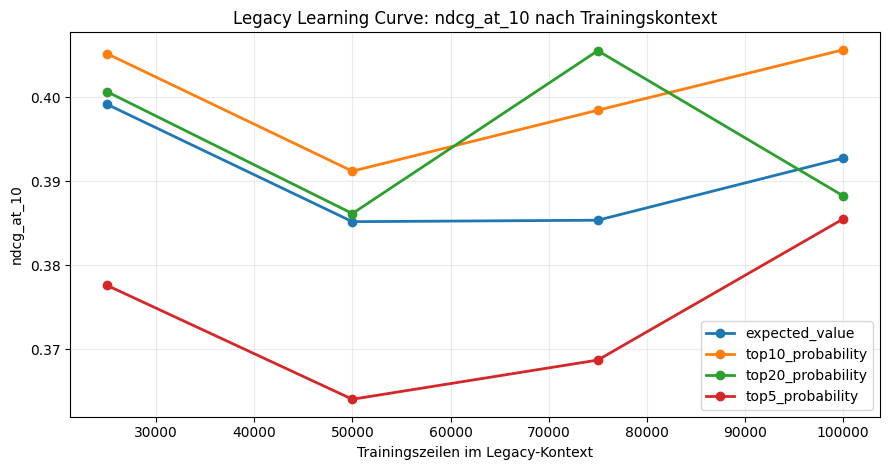

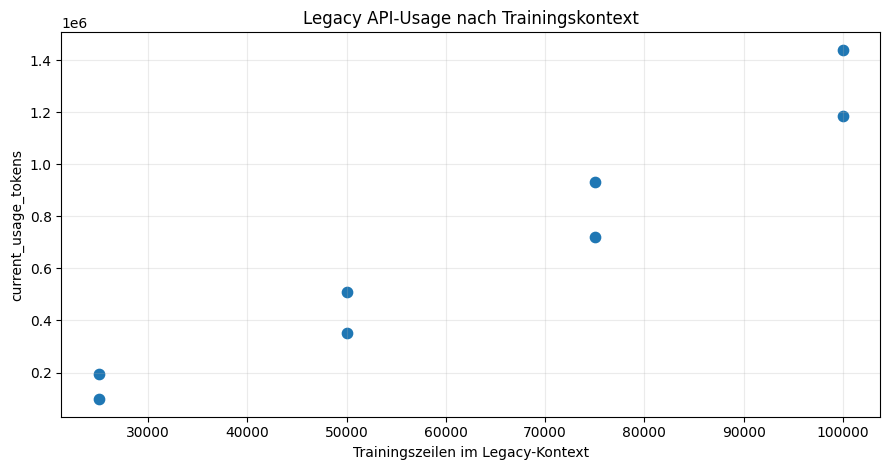

,artifact,exists_after_cell
0,legacy_learning_curve_roc_auc.png,True
1,legacy_learning_curve_usage.png,True


In [6]:
# Leseschlüssel für die Chart-Zelle:
# 1. Charts werden nur erzeugt, wenn matplotlib und passende Daten verfügbar sind.
# 2. Die Metrik-Kurve zeigt historische Performance-Trends, nicht die finale Auswahl.
# 3. Die Usage-Grafik hilft, alte API-Kosten im Verhältnis zur Kontextgröße zu lesen.

# Die optionalen Charts visualisieren alte Trends, ersetzen aber keine neue Validierung.

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    warnings.warn(f"matplotlib nicht verfügbar: {exc}")

if plt is not None and not classifier_summary.empty:
    metric = "roc_auc" if "roc_auc" in classifier_summary.columns else "ndcg_at_10"
    fig, ax = plt.subplots(figsize=(9, 4.8))
    if "score_name" in classifier_summary.columns:
        grouped_classifier_summary = classifier_summary.groupby("score_name")
    else:
        grouped_classifier_summary = [("classifier", classifier_summary)]
    for score_name, part in grouped_classifier_summary:
        part = part.sort_values("target_rows")
        ax.plot(part["target_rows"], part[metric], marker="o", linewidth=2, label=str(score_name))
    ax.set_title(f"Legacy Learning Curve: {metric} nach Trainingskontext", fontsize=12)
    ax.set_xlabel("Trainingszeilen im Legacy-Kontext")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    fig.tight_layout()
    fig.savefig(RESULT_DIR / "legacy_learning_curve_roc_auc.png", dpi=160)
    plt.show()

if plt is not None and not usage_summary.empty and {"target_rows", "current_usage_tokens"}.issubset(usage_summary.columns):
    usage_plot = usage_summary[usage_summary.get("checkpoint", "") == "after_predict"].copy()
    if usage_plot.empty:
        usage_plot = usage_summary.copy()
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.scatter(usage_plot["target_rows"], usage_plot["current_usage_tokens"], s=55)
    ax.set_title("Legacy API-Usage nach Trainingskontext", fontsize=12)
    ax.set_xlabel("Trainingszeilen im Legacy-Kontext")
    ax.set_ylabel("current_usage_tokens")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(RESULT_DIR / "legacy_learning_curve_usage.png", dpi=160)
    plt.show()

chart_exports = pd.DataFrame([
    {"artifact": "legacy_learning_curve_roc_auc.png", "exists_after_cell": (RESULT_DIR / "legacy_learning_curve_roc_auc.png").exists()},
    {"artifact": "legacy_learning_curve_usage.png", "exists_after_cell": (RESULT_DIR / "legacy_learning_curve_usage.png").exists()},
])

display(chart_exports)

### Interpretation der Visualisierungen

Die Visualisierungen sind als historische Diagnose zu lesen. Sie machen Trends leichter sichtbar als reine CSV-Tabellen. Für die Thesis sollte dennoch klar formuliert werden, dass diese Charts keine neue Hyperparameterentscheidung treffen.

## Ergebnisrolle und Fazit

Diese Analyse bleibt ein methodischer Vorlauf. Die neuen Hyperparameter werden in `12-02` mit den aktuellen `data/model_data`-Splits und dem `Top10`-`roc_auc` validiert.

Das wichtigste Ergebnis dieses Notebooks ist deshalb nicht ein Gewinner-Setup, sondern eine transparente Einordnung der alten TabPFN-Versuche.

### Fazit im Verhältnis zu `12-02`

Dieses Notebook endet bewusst ohne finale Parameterwahl. Sein Nutzen liegt darin, Erwartungen zu kalibrieren: Welche Größenordnung an Kontext wurde früher getestet? Welche Verbrauchsdaten existieren? Welche alten Classifier-Zeilen sind überhaupt noch methodisch anschlussfähig? Die Antwort auf die eigentliche Auswahlfrage liefert erst das nächste Notebook.